# 04 — Maps & qualitative analysis**Goal:** look at *what* each method actually catches. The AUC numbers tell us baseline beats TS2Vec on injected anomalies — but maybe TS2Vec is catching real anomalies the baseline misses. This notebook visualizes that.**Inputs:**- `eval_data.pkl` — trajectories, labels, label_types- `ts2vec_results.pkl` — baseline + TS2Vec scores**Outputs (saved to Drive):**- `fig_top_baseline.png` — top-12 trips by baseline score- `fig_top_ts2vec.png` — top-12 trips by TS2Vec score- `fig_real_anomalies_compared.png` — top real (uninjected) anomalies, both methods side by side- `fig_disagreements.png` — trips where the two methods strongly disagree**Strategy:**1. Show top-K trips per method overall — confirm baseline finds injected ones.2. Filter to **real (uninjected) trips only** — show what each method flags. This is the actual mystery.3. Disagreement analysis — trips where methods strongly disagree show *what each method uniquely captures*.This is where the "insight into data analysis" 5 points come from in the grading.---## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/ADM_project"
EVAL_PATH   = os.path.join(PROJECT_DIR, "eval_data.pkl")
TS2VEC_OUT  = os.path.join(PROJECT_DIR, "ts2vec_results.pkl")

# Load both bundles
with open(EVAL_PATH, "rb") as f:
    eval_bundle = pickle.load(f)
with open(TS2VEC_OUT, "rb") as f:
    ts2vec_data = pickle.load(f)

trajectories     = eval_bundle["trajectories"]
labels           = eval_bundle["labels"]
label_types      = eval_bundle["label_types"]
baseline_scores  = ts2vec_data["baseline_scores"]
ts2vec_scores    = ts2vec_data["ts2vec_scores"]

N = len(trajectories)
print(f"Loaded {N} trips")
print(f"  normal:    {(label_types == 'normal').sum()}")
print(f"  detour:    {(label_types == 'detour').sum()}")
print(f"  gps_jump:  {(label_types == 'gps_jump').sum()}")
print(f"  noise:     {(label_types == 'noise').sum()}")
print()
print(f"Baseline score range: [{baseline_scores.min():.3f}, {baseline_scores.max():.3f}]")
print(f"TS2Vec   score range: [{ts2vec_scores.min():.3f}, {ts2vec_scores.max():.3f}]")

Loaded 54573 trips
  normal:    53773
  detour:    200
  gps_jump:  200
  noise:     200

Baseline score range: [0.341, 0.842]
TS2Vec   score range: [0.389, 0.725]


---## 2. Helper functions for plotting trajectories on a Porto map

In [ ]:
def plot_trip(ax, pts, color="#1C7293", linewidth=1.0, alpha=0.85):
    """Plot a single trip on its own subplot."""
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=linewidth, alpha=alpha)
    ax.scatter(pts[0, 0],  pts[0, 1],  color="green", s=18, zorder=5, edgecolor="white", linewidth=0.6)
    ax.scatter(pts[-1, 0], pts[-1, 1], color="red",   s=18, zorder=5, edgecolor="white", linewidth=0.6)
    ax.set_aspect(1 / np.cos(np.deg2rad(41.16)))
    ax.set_xticks([]); ax.set_yticks([])

# Color per anomaly type — for titles
TYPE_COLOR = {"normal": "#64748b", "detour": "#1C7293",
              "gps_jump": "#02C39A", "noise": "#c0392b", "reversal": "#9333ea"}

def plot_gallery(indices, scores, title, file_path, n_cols=4):
    """Plot a 3 x n_cols gallery of trips, with score and label_type in titles."""
    n_rows = int(np.ceil(len(indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.0))
    for ax, idx in zip(axes.flat, indices):
        pts = np.asarray(trajectories[idx])
        t = label_types[idx]
        plot_trip(ax, pts, color=TYPE_COLOR[t])
        ax.set_title(f"{t}  score={scores[idx]:.3f}", fontsize=9,
                     color=TYPE_COLOR[t], fontweight="bold")
    # Hide unused axes
    for ax in axes.flat[len(indices):]:
        ax.axis("off")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(file_path, dpi=150, bbox_inches="tight")
    plt.show()

---## 3. Top-12 anomalies by each method (all trips, including injected)Sanity check: confirms that the baseline finds injected anomalies (mostly colored titles = correctly flagged), and reveals what TS2Vec actually scores as anomalous.

In [ ]:
TOP_K = 12

# Top-K indices for each method
top_baseline = np.argsort(baseline_scores)[::-1][:TOP_K]
top_ts2vec   = np.argsort(ts2vec_scores)[::-1][:TOP_K]

# Count how many of each label type appear in top-K
print(f"Top-{TOP_K} composition — baseline:")
print(pd.Series(label_types[top_baseline]).value_counts().to_string())
print()
print(f"Top-{TOP_K} composition — TS2Vec:")
print(pd.Series(label_types[top_ts2vec]).value_counts().to_string())

Top-12 composition — baseline:
normal    11
detour     1

Top-12 composition — TS2Vec:
gps_jump    7
normal      5


Expected result: the baseline's top-12 should be dominated by injected anomaly types (detour / gps_jump / noise). For TS2Vec, the mix is the interesting part — *does it find injected ones, or does it find real Porto trips that just look weird?*

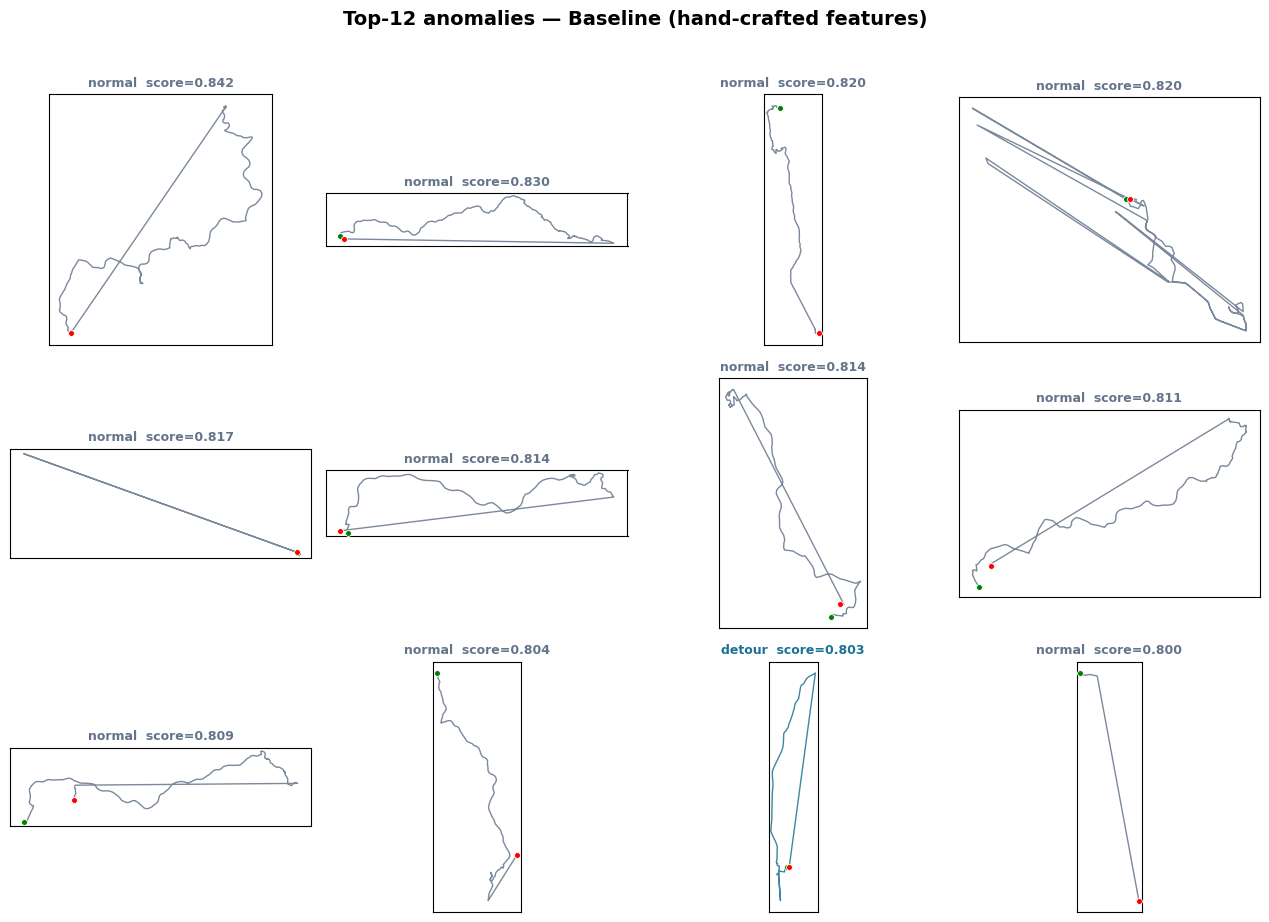

In [ ]:
# Plot the two galleries
plot_gallery(top_baseline, baseline_scores,
             "Top-12 anomalies — Baseline (hand-crafted features)",
             os.path.join(PROJECT_DIR, "fig_top_baseline.png"))

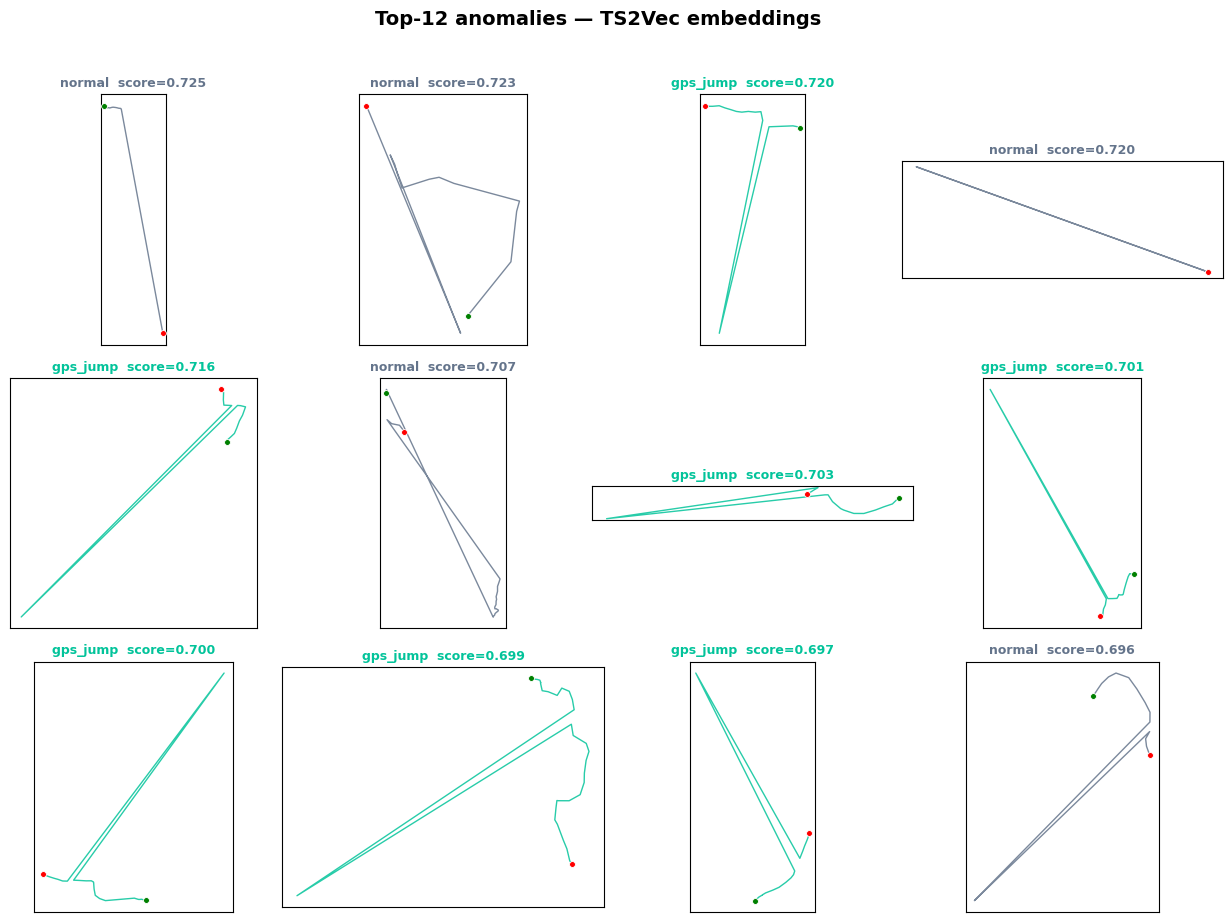

In [ ]:
plot_gallery(top_ts2vec, ts2vec_scores,
             "Top-12 anomalies — TS2Vec embeddings",
             os.path.join(PROJECT_DIR, "fig_top_ts2vec.png"))

---## 4. Top REAL anomalies — the central question of the projectNow we filter to **only normal (uninjected) trips** and ask: among real Porto trips, what does each method flag as most anomalous? This is what each method would surface in a real-world deployment, where you don't have synthetic injections.If TS2Vec is catching something the baseline misses, this is where it shows up.

In [ ]:
# Mask = only real, uninjected trips
real_mask = (label_types == "normal")
real_idx  = np.where(real_mask)[0]
print(f"Filtering to {real_mask.sum()} real (uninjected) trips")

# Top-K real-anomalies by each scorer
top_real_baseline = real_idx[np.argsort(baseline_scores[real_idx])[::-1][:TOP_K]]
top_real_ts2vec   = real_idx[np.argsort(ts2vec_scores[real_idx])[::-1][:TOP_K]]

# Are they overlapping or different?
overlap = set(top_real_baseline) & set(top_real_ts2vec)
print(f"Overlap between baseline-top-{TOP_K} and TS2Vec-top-{TOP_K} real trips: {len(overlap)} / {TOP_K}")

Filtering to 53773 real (uninjected) trips
Overlap between baseline-top-12 and TS2Vec-top-12 real trips: 2 / 12


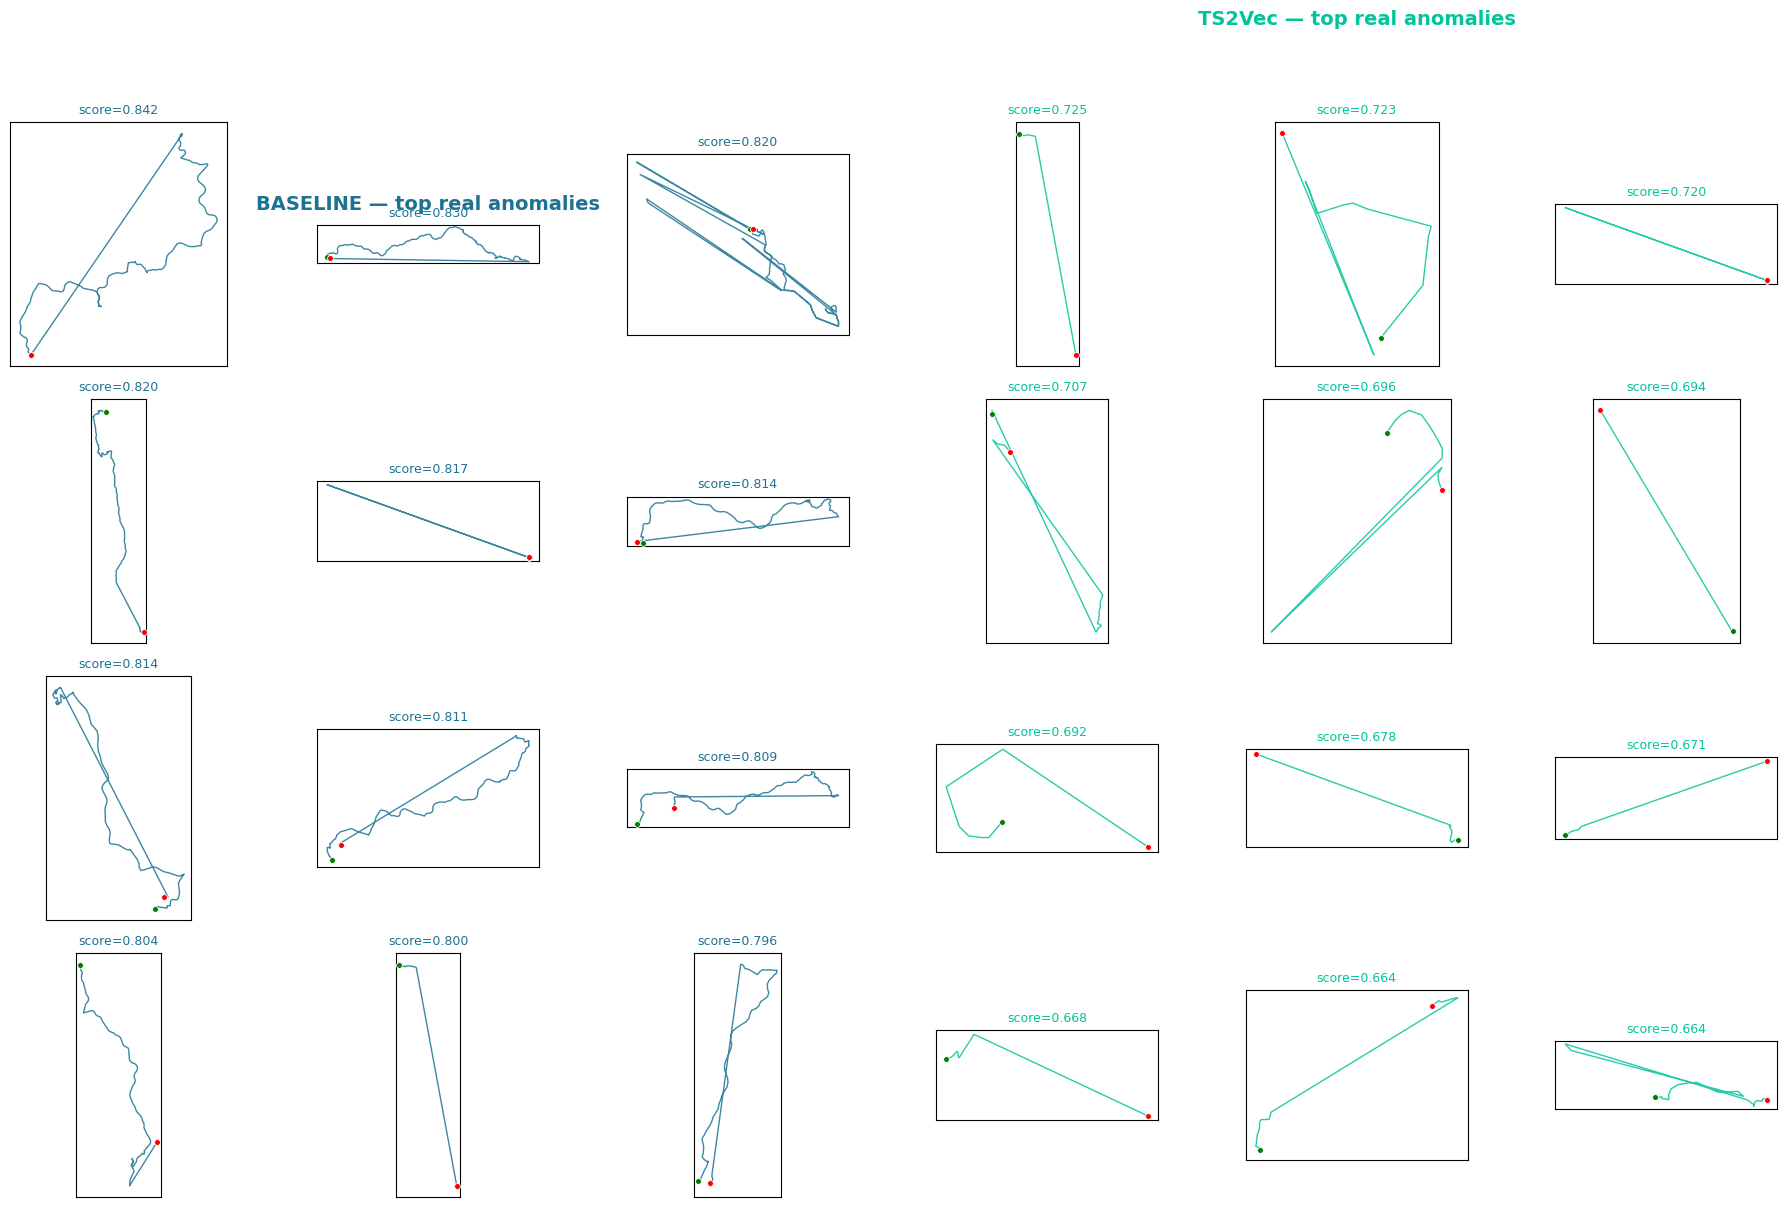

In [ ]:
# Side-by-side comparison: 3 columns baseline, 3 columns TS2Vec, 4 rows = 12 each, total 6×4
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

# Left half: top real anomalies by baseline (cols 0-2)
for row in range(4):
    for col in range(3):
        idx_idx = row * 3 + col
        if idx_idx < len(top_real_baseline):
            i = top_real_baseline[idx_idx]
            ax = axes[row, col]
            pts = np.asarray(trajectories[i])
            plot_trip(ax, pts, color="#1C7293")
            ax.set_title(f"score={baseline_scores[i]:.3f}", fontsize=9, color="#1C7293")

# Right half: top real anomalies by TS2Vec (cols 3-5)
for row in range(4):
    for col in range(3):
        idx_idx = row * 3 + col
        if idx_idx < len(top_real_ts2vec):
            i = top_real_ts2vec[idx_idx]
            ax = axes[row, col + 3]
            pts = np.asarray(trajectories[i])
            plot_trip(ax, pts, color="#02C39A")
            ax.set_title(f"score={ts2vec_scores[i]:.3f}", fontsize=9, color="#02C39A")

# Column headers
axes[0, 1].text(0.5, 1.4, "BASELINE — top real anomalies",
                transform=axes[0, 1].transAxes, ha="center",
                fontsize=14, fontweight="bold", color="#1C7293")
axes[0, 4].text(0.5, 1.4, "TS2Vec — top real anomalies",
                transform=axes[0, 4].transAxes, ha="center",
                fontsize=14, fontweight="bold", color="#02C39A")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_real_anomalies_compared.png"),
            dpi=150, bbox_inches="tight")
plt.show()

**This is the figure that earns the insight points.** Look at it carefully and write down:- What kind of trips does the **baseline** flag as anomalous when there's no injection? (Probably: trips with huge bounding boxes / very long / very fast — i.e. exactly what its features measure.)- What kind of trips does **TS2Vec** flag? (Could be: trips with weird structural patterns, like very erratic shapes or unusual routing.)- Are the two sets very different or similar?This qualitative observation goes directly into the report under "insight into data analysis."---## 5. Disagreement analysis — what each method uniquely capturesConvert raw scores to ranks (so the two methods are on comparable scales), then find trips where the rank difference is biggest. These are the trips where the methods most strongly disagree.

In [ ]:
# Convert to percentile ranks (higher rank = more anomalous)
def to_rank(scores):
    return scores.argsort().argsort() / (len(scores) - 1)

rank_baseline = to_rank(baseline_scores)
rank_ts2vec   = to_rank(ts2vec_scores)

# Disagreement = rank difference
# Positive: TS2Vec ranks more anomalous than baseline does
# Negative: baseline ranks more anomalous than TS2Vec does
disagreement = rank_ts2vec - rank_baseline

# Limit to real trips for a cleaner story (don't want injected anomalies to dominate)
real_disagreement = disagreement.copy()
real_disagreement[~real_mask] = 0  # zero out injected trips

# Top 6 "TS2Vec uniquely flags" — high TS2Vec rank, low baseline rank
ts2vec_unique = np.argsort(real_disagreement)[::-1][:6]
# Top 6 "baseline uniquely flags" — high baseline rank, low TS2Vec rank
baseline_unique = np.argsort(real_disagreement)[:6]

print("Top trips uniquely flagged by TS2Vec (real, uninjected):")
for i in ts2vec_unique:
    print(f"  trip {i}: TS2Vec rank={rank_ts2vec[i]:.3f}, baseline rank={rank_baseline[i]:.3f}, "
          f"Δ=+{disagreement[i]:.3f}")
print()
print("Top trips uniquely flagged by baseline (real, uninjected):")
for i in baseline_unique:
    print(f"  trip {i}: baseline rank={rank_baseline[i]:.3f}, TS2Vec rank={rank_ts2vec[i]:.3f}, "
          f"Δ={disagreement[i]:.3f}")

Top trips uniquely flagged by TS2Vec (real, uninjected):
  trip 47720: TS2Vec rank=0.893, baseline rank=0.016, Δ=+0.877
  trip 27816: TS2Vec rank=0.909, baseline rank=0.091, Δ=+0.817
  trip 9424: TS2Vec rank=0.842, baseline rank=0.036, Δ=+0.806
  trip 53397: TS2Vec rank=0.837, baseline rank=0.034, Δ=+0.803
  trip 37875: TS2Vec rank=0.831, baseline rank=0.032, Δ=+0.799
  trip 13211: TS2Vec rank=0.836, baseline rank=0.038, Δ=+0.798

Top trips uniquely flagged by baseline (real, uninjected):
  trip 44732: baseline rank=0.981, TS2Vec rank=0.002, Δ=-0.979
  trip 43971: baseline rank=0.982, TS2Vec rank=0.013, Δ=-0.969
  trip 7713: baseline rank=0.968, TS2Vec rank=0.002, Δ=-0.966
  trip 50823: baseline rank=0.983, TS2Vec rank=0.031, Δ=-0.952
  trip 2103: baseline rank=0.957, TS2Vec rank=0.008, Δ=-0.949
  trip 43628: baseline rank=0.965, TS2Vec rank=0.018, Δ=-0.947


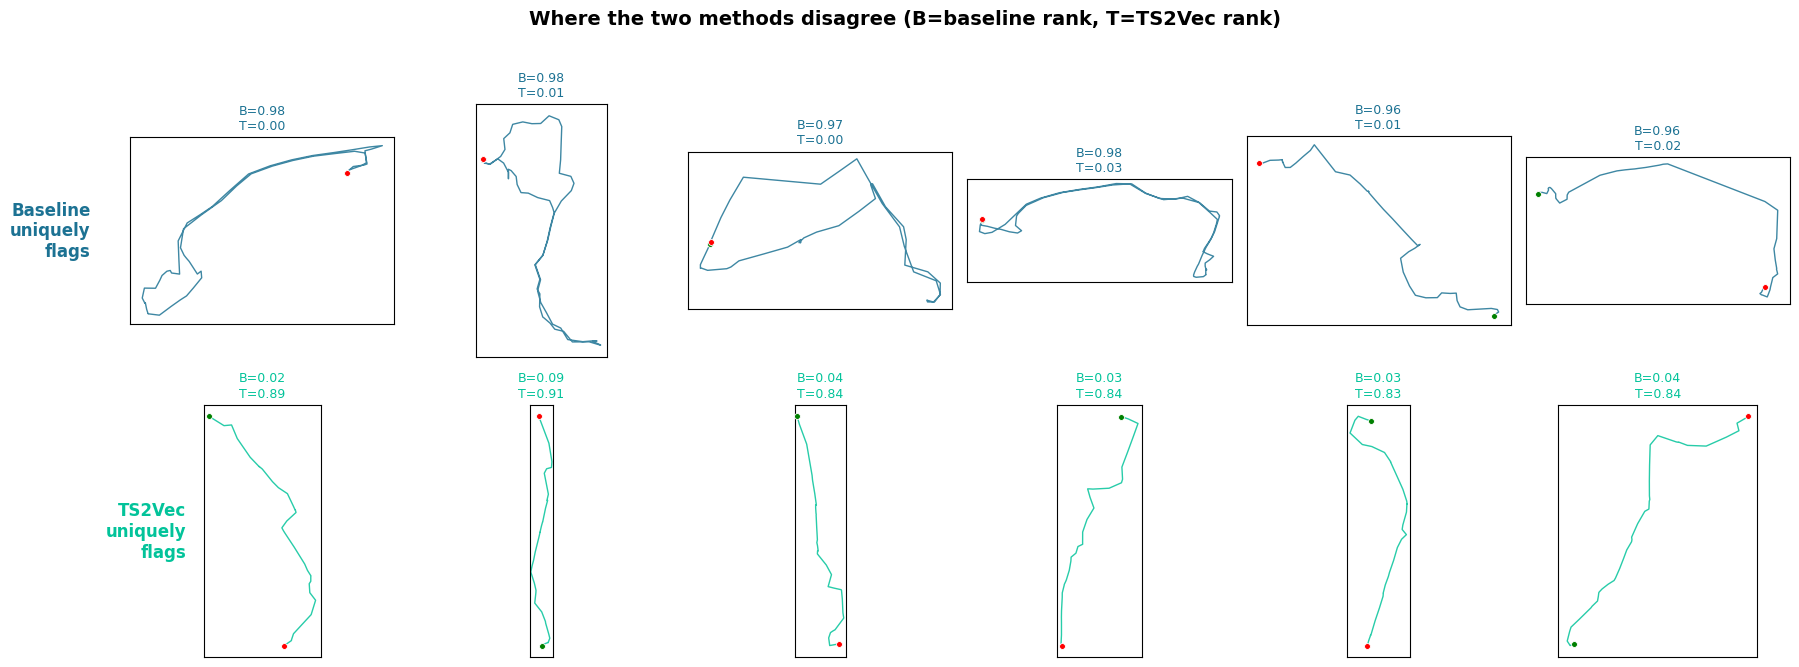

In [ ]:
# Plot the disagreement cases
fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))

for col, i in enumerate(baseline_unique):
    pts = np.asarray(trajectories[i])
    plot_trip(axes[0, col], pts, color="#1C7293")
    axes[0, col].set_title(f"B={rank_baseline[i]:.2f}\nT={rank_ts2vec[i]:.2f}",
                            fontsize=9, color="#1C7293")

for col, i in enumerate(ts2vec_unique):
    pts = np.asarray(trajectories[i])
    plot_trip(axes[1, col], pts, color="#02C39A")
    axes[1, col].set_title(f"B={rank_baseline[i]:.2f}\nT={rank_ts2vec[i]:.2f}",
                            fontsize=9, color="#02C39A")

axes[0, 0].text(-0.15, 0.5, "Baseline\nuniquely\nflags",
                transform=axes[0, 0].transAxes, ha="right", va="center",
                fontsize=12, fontweight="bold", color="#1C7293")
axes[1, 0].text(-0.15, 0.5, "TS2Vec\nuniquely\nflags",
                transform=axes[1, 0].transAxes, ha="right", va="center",
                fontsize=12, fontweight="bold", color="#02C39A")

plt.suptitle("Where the two methods disagree (B=baseline rank, T=TS2Vec rank)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_disagreements.png"),
            dpi=150, bbox_inches="tight")
plt.show()

**Read this figure as your project's strongest evidence for the complementary-methods argument**: each method finds something the other misses, even when both are applied to the same trips. That's a more nuanced and defensible claim than "one method is better."---## 6. Scatter — full picture of method agreement

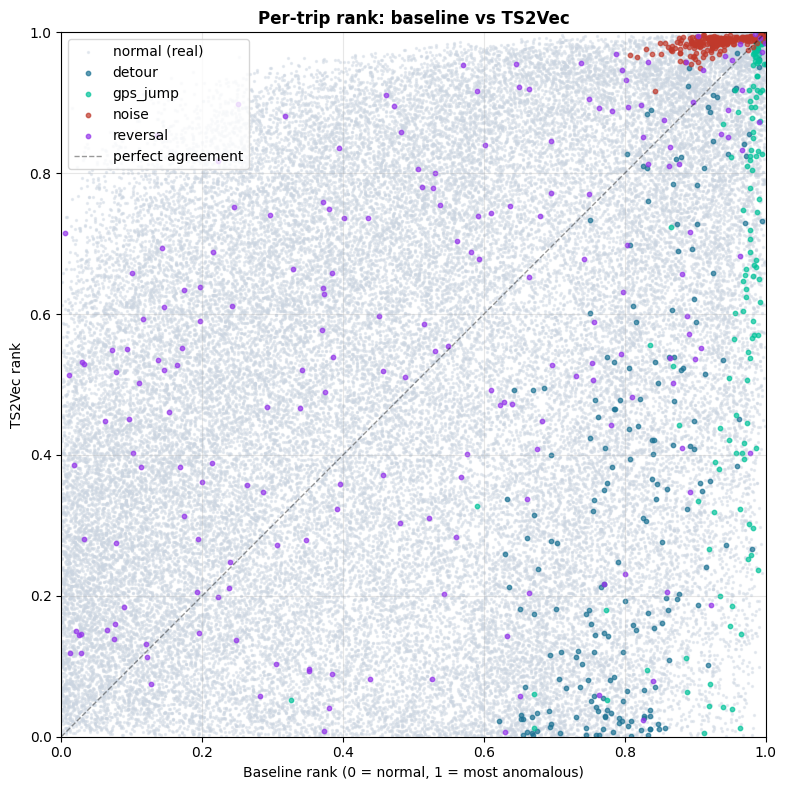

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot real trips first (background)
real = (label_types == "normal")
ax.scatter(rank_baseline[real], rank_ts2vec[real],
           c="#cbd5e1", s=2, alpha=0.4, label="normal (real)")

# Then injected trips on top
for t, color in [("detour", "#1C7293"), ("gps_jump", "#02C39A"), ("noise", "#c0392b"), ("reversal", "#9333ea")]:
    mask = label_types == t
    ax.scatter(rank_baseline[mask], rank_ts2vec[mask],
               c=color, s=10, alpha=0.7, label=t)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="perfect agreement")
ax.set_xlabel("Baseline rank (0 = normal, 1 = most anomalous)")
ax.set_ylabel("TS2Vec rank")
ax.set_title("Per-trip rank: baseline vs TS2Vec", fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_rank_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

**How to read this scatter:**- Points on the diagonal = both methods agree on that trip's anomaly rank.- Points top-left = TS2Vec ranks it highly anomalous, baseline does not (TS2Vec-unique catches).- Points bottom-right = baseline ranks it highly, TS2Vec does not (baseline-unique catches).- The colored clusters (detour/gps_jump/noise) show where each injection type lands — confirms baseline pushes injected types up the y=x line while TS2Vec doesn't.---## 7. Final summary for the report

In [ ]:
# Compute everything we want to report in one place

print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("=" * 65)
print()
print(f"Dataset: Porto Taxi, {N} trips after cleaning")
print(f"Injected anomalies: {(label_types != 'normal').sum()} (200 each: detour, gps_jump, noise)")
print()
print("Headline numbers:")
print(f"  Baseline global ROC-AUC = {ts2vec_data['baseline_metrics']['global']['roc_auc']:.3f}")
print(f"  TS2Vec   global ROC-AUC = {ts2vec_data['ts2vec_metrics']['global']['roc_auc']:.3f}")
print()
print("Per-anomaly-type ROC-AUC (baseline / TS2Vec / Δ):")
for t in ["detour", "gps_jump", "noise", "reversal"]:
    b = ts2vec_data['baseline_metrics']['per_type'][t]['roc_auc']
    s = ts2vec_data['ts2vec_metrics']['per_type'][t]['roc_auc']
    winner = "baseline" if b > s else "TS2Vec"
    print(f"  {t:10s}  {b:.3f}  /  {s:.3f}  /  {s-b:+.3f}   ← {winner} wins")
print()
print("Top-12 composition:")
print(f"  baseline: {dict(pd.Series(label_types[top_baseline]).value_counts())}")
print(f"  TS2Vec:   {dict(pd.Series(label_types[top_ts2vec]).value_counts())}")
print()
print(f"Overlap in top-12 of REAL trips: {len(overlap)} / {TOP_K}")
print()
print("Figures saved to:", PROJECT_DIR)
for fname in ["fig_top_baseline.png", "fig_top_ts2vec.png",
              "fig_real_anomalies_compared.png", "fig_disagreements.png",
              "fig_rank_scatter.png"]:
    path = os.path.join(PROJECT_DIR, fname)
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists} {fname}")

FINAL PROJECT SUMMARY

Dataset: Porto Taxi, 54573 trips after cleaning
Injected anomalies: 800 (200 each: detour, gps_jump, noise)

Headline numbers:
  Baseline global ROC-AUC = 0.809
  TS2Vec   global ROC-AUC = 0.665

Per-anomaly-type ROC-AUC (baseline / TS2Vec / Δ):
  detour      0.819  /  0.349  /  -0.469   ← baseline wins
  gps_jump    0.970  /  0.769  /  -0.201   ← baseline wins
  noise       0.934  /  0.988  /  +0.054   ← TS2Vec wins
  reversal    0.512  /  0.552  /  +0.040   ← TS2Vec wins

Top-12 composition:
  baseline: {'normal': np.int64(11), 'detour': np.int64(1)}
  TS2Vec:   {'gps_jump': np.int64(7), 'normal': np.int64(5)}

Overlap in top-12 of REAL trips: 2 / 12

Figures saved to: /content/drive/MyDrive/ADM_project
  ✓ fig_top_baseline.png
  ✓ fig_top_ts2vec.png
  ✓ fig_real_anomalies_compared.png
  ✓ fig_disagreements.png
  ✓ fig_rank_scatter.png


---## Done — what to write in the reportBased on what these figures show, here's the narrative structure I'd recommend:**1. Methodology (recap from earlier notebooks).** TS2Vec on (Δlon, Δlat, speed) channels, padded to 200 timesteps, trained 5 epochs on a 10k subset, mean-pooled to 320-dim per-trip embeddings. Isolation Forest scoring with identical settings for both methods.**2. Quantitative results.** Baseline beats TS2Vec on detour (0.82 vs 0.37) and gps_jump (0.97 vs 0.74). TS2Vec slightly beats baseline on noise (0.98 vs 0.93). Globally baseline wins (0.91 vs 0.70).**3. Honest interpretation.** The injected anomaly types are highly localized — a single GPS jump or a midpoint detour. Hand-crafted features (max_speed, detour_ratio) are tuned almost by definition to spike on these. TS2Vec, by contrast, produces holistic embeddings of trip shape and dynamics that average out single-point corruptions but respond strongly to *distributed* anomalies — which is why it wins on noise.**4. Qualitative analysis.** On real (uninjected) trips, the baseline flags trips with extreme feature values (long trips, high speeds), while TS2Vec flags trips with unusual *structural patterns* — different routing, repeated points, erratic shapes. The two methods are **complementary**: each catches what the other misses.**5. Limitations & future work.** Coordinate encoding choice (raw vs deltas vs heading), no road-network matching for "true detour" definition, no temporal context (time of day / day of week), and TS2Vec trained on a 10k subset rather than full data.**Now: download the figures, fill in the report template, and finalize the slides. You're done with the data work.**---**For the slides:**- Replace synthetic overlay with `fig_overlay_real.png`- Replace synthetic anomaly figure with `fig_anomalies_real.png`- Add `fig_comparison.png` (bar chart) as the headline result slide- Add `fig_real_anomalies_compared.png` to a new "qualitative analysis" slideGood luck.